# 09 — Galaxy (halo) bias of the ζ₁ production samples

**Goal.** Put a number on the large-scale linear bias `b` of the halo samples this project
measures ζ₁ on, so the linear prediction

$$\zeta_1(r) \;=\; -\,\frac{b\,aHf}{6\pi^2}\int \mathrm{d}k\;k\,P_{\rm lin}(k)\,j_1(kr)$$

can be overlaid on a measurement rather than fitted to it.

**Definitions** — the large-scale, linear, **real-space** ones, at the snapshot redshift
(z = 0), on raw MDPL2 box coordinates (λ = 0, never `dvcorr.redshift_space`'s displaced
coordinates), on the exact production sample (`CatalogConfig()` — full catalog, no mass cut,
subhalos included):

| estimate | definition | role |
|---|---|---|
| $b_{\rm cross}(r)$ | $\xi_{hm}/\xi_{mm}$ | **primary** — linear in $b$, insensitive to halo shot noise |
| $b_{\rm auto}(r)$ | $\sqrt{\xi_{hh}/\xi_{mm}}$ | consistency check |
| $r_{cc}(r)$ | $\xi_{hm}/\sqrt{\xi_{hh}\xi_{mm}}$ | stochasticity — must be 1.00 to a few % over 20–60 |

**Acceptance criterion is flatness.** A number without the $b(r)$ plot is not a measurement.

**Order.** The particle-free ratio test (§1) runs *before* the absolute bias (§2), because it
needs no matter field at all and it is the one that can falsify the estimator.

This notebook is a thin consumer (CLAUDE.md's working model): every stage function lives in
[src/dvcorr/pipeline/galaxy_bias.py](../src/dvcorr/pipeline/galaxy_bias.py) and the ζ₁ runs go
through the unchanged [velocity_centered](../src/dvcorr/pipeline/velocity_centered.py) pipeline.

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np

from dvcorr import conventions
from dvcorr.config import CatalogConfig, CosmologyConfig, PathsConfig
from dvcorr.config.catalog import (
    CATALOG_FULL,
    CATALOG_MVIR12,
    MVIR12_CATALOG_FLOOR,
    MVIR12_CATALOG_ROWS,
)
from dvcorr.pipeline import galaxy_bias as gb
from dvcorr.pipeline.velocity_centered import (
    RunConfig,
    box_number_density,
    draw_candidates,
    load_and_carve,
    normalize_result,
    run_estimator,
)

paths = PathsConfig()
cosmology = CosmologyConfig()
observer = np.asarray(conventions.OBSERVER_POSITION, dtype=float)

PRODUCTION = CatalogConfig()                              # full, no mass cut, subhalos in
REFERENCE = CatalogConfig(name=CATALOG_MVIR12)            # mvir >= 1e12, distinct only
REPORT_RADII = np.array([20.0, 30.0, 40.0, 60.0])         # where the ratios get tabulated

bias_cfg = {
    "full": gb.BiasRunConfig(catalog=PRODUCTION),
    "mvir12": gb.BiasRunConfig(catalog=REFERENCE),
}
print(f"ratio fit range    : {gb.FIT_MIN_RADIUS:.0f}-{gb.FIT_MAX_RADIUS:.0f} h^-1 Mpc")
print(f"absolute-b fit range: {gb.ABSOLUTE_BIAS_MIN_RADIUS:.0f}-{gb.FIT_MAX_RADIUS:.0f} h^-1 Mpc")
print(f"xi binning         : {gb.XI_N_BINS} log bins, "
      f"{gb.XI_MIN_RADIUS:.0f}-{gb.XI_MAX_RADIUS:.0f} h^-1 Mpc")
print(f"threads            : {bias_cfg['full'].n_threads}")
for tag, cfg in bias_cfg.items():
    print(f"  {tag:7s}: {cfg.catalog.describe_cuts()}  (cap {cfg.max_tracers:,} tracers)")


def at_radii(r, y, targets=REPORT_RADII):
    '''Log-interpolate y(r) onto the reporting radii, shape (len(targets),).'''
    finite = np.isfinite(y)
    return np.interp(np.log(targets), np.log(np.asarray(r)[finite]), np.asarray(y)[finite])

ratio fit range    : 20-60 h^-1 Mpc
absolute-b fit range: 30-60 h^-1 Mpc
xi binning         : 24 log bins, 1-120 h^-1 Mpc
threads            : 8
  full   : full, no mass cut, subhalos included  (cap 8,000,000 tracers)
  mvir12 : mvir12, no mass cut, subhalos included  (cap 8,000,000 tracers)


---
## 0. The matter field — read this before trusting any absolute `b` below

$\xi_{mm}$ and $\xi_{hm}$ need the dark-matter particles. **MDPL2 does not distribute a
downsampled particle set.** What was actually checked:

In [2]:
print(gb.MATTER_FIELD_AVAILABILITY)

MDPL2 has NO downsampled particle table. The CosmoSim TAP tableset (https://www.cosmosim.org/tap/tables) lists exactly 13 mdpl2.* tables -- availhalos, fof, fof1-5, galacticus, linklength, redshifts, rockstar, sag, sage -- and no particle table; the equivalents that DO exist for the older runs (bolshoi_particles, mdr1_particles) have no mdpl2 counterpart. The only MDPL2 particle product is the full GADGET snapshot (snapdir_130 = z = 0): 1270 files, ~1.1 TB, login-gated (HTTP 403 unauthenticated), and spatially decomposed, so a partial download is a contiguous sub-region rather than a fair subsample and would need Landy-Szalay against its own footprint. Skies & Universes lists particle sets for MDPL/SMD/BigMD but not for MDPL2, and its download host (astronomy.nmsu.edu/aklypin/SUsimulations) no longer serves them.


So the steps that need particles — measured $\xi_{mm}$, $\xi_{hm}$, $b_{\rm cross}$, $r_{cc}$
— are **not measured here**, and $b_{\rm cross}$/$r_{cc}$ come back all-NaN by construction
rather than by accident. Three routes that need no particles carry the result instead: the
ratio test (§1), $b_{\rm auto}$ against a CAMB **linear** $\xi_{mm}$ tagged PLACEHOLDER (§2),
and the Tinker mass function (§3).

---
## 1. The particle-free ratio test

Two samples measured with the **same estimator** in the **same box** differ in ζ₁ amplitude
only through their tracer bias: the velocity field they are correlated against is the same
unbiased field. So

$$\sqrt{\frac{\xi_{hh}^{\rm full}}{\xi_{hh}^{M>10^{12}}}} \;=\;
\frac{b_{\rm full}}{b_{M>10^{12}}} \;=\;
\frac{\zeta_1^{\rm full}(r)}{\zeta_1^{M>10^{12}}(r)},$$

flat in $r$ over 20–60 $h^{-1}$Mpc. **$\xi_{mm}$ and the box's sample variance cancel exactly
in both ratios**, so this is a clean test with no theory in it: if the two agree the estimator
tracks the density amplitude correctly; if they disagree the bug is in the estimator.

In [3]:
# --- xi_hh for both samples (periodic-box natural estimator, no randoms needed) ---
xi_hh, samples = {}, {}
for tag, cfg in bias_cfg.items():
    t = time.time()
    samples[tag] = gb.load_tracer_positions(cfg, paths)
    xi_hh[tag] = gb.periodic_auto_xi(samples[tag], cfg, f"$\\xi_{{hh}}$ ({tag})")
    s = samples[tag]
    print(f"{tag:7s}: {s.n_total:,} halos -> {s.n_used:,} pair-counted"
          f"{' (random subsample)' if s.subsampled else ''}, {time.time()-t:.0f}s")

r_grid = xi_hh["full"].r_eff
ratio_hh = xi_hh["full"].xi / xi_hh["mvir12"].xi
bias_ratio_curve = np.sqrt(np.where(ratio_hh > 0, ratio_hh, np.nan))
bias_ratio_fit = gb.fit_constant(r_grid, bias_ratio_curve,
                                 gb.FIT_MIN_RADIUS, gb.FIT_MAX_RADIUS)
print("\nb_full / b_mvir12  from xi_hh :", bias_ratio_fit.summary())

full   : 127,388,160 halos -> 8,000,000 pair-counted (random subsample), 348s


mvir12 : 4,093,751 halos -> 4,093,751 pair-counted, 89s

b_full / b_mvir12  from xi_hh : 0.8659 +/- 0.0075 (scatter across 5 bins, 20-60 h^-1 Mpc; 0.9%, trend +0.0532/dex)


In [4]:
# --- zeta_1 for both samples, through the unchanged production pipeline ---
zeta = {}
for tag, catalog in (("full", PRODUCTION), ("mvir12", REFERENCE)):
    cfg = RunConfig(catalog=catalog)
    t = time.time()
    carved = load_and_carve(cfg, paths)
    candidates = draw_candidates(cfg, carved)
    result = run_estimator(cfg, candidates.s, candidates.v, carved.pos, observer)
    normalized = normalize_result(result, box_number_density(carved.n_total),
                                  cfg.shuffle_seed, cfg.gaussian_null_seed,
                                  cfg.n_null_realizations)
    zeta[tag] = (cfg, result, normalized)
    print(f"{tag:7s}: {result.n_centers} centers of {carved.n_carved:,} carved, "
          f"{time.time()-t:.0f}s")
    del carved, candidates

loading mdpl2_rockstar_snapnum125.parquet [full, no mass cut, subhalos included] ...


loaded 127388160 halos (0 removed by in-memory cuts)


carved 14418601 of 127388160 halos within sub_volume_radius = 300.0 h^-1 Mpc (11.32%)


n_candidates = 16000, n_centers = 7726 (48.3% survive the core cut)
full   : 7726 centers of 14,418,601 carved, 283s
loading mdpl2_rockstar_125_pid-1_mvir12.parquet [mvir12, no mass cut, subhalos included] ...


loaded 4093751 halos (0 removed by in-memory cuts)


carved 464764 of 4093751 halos within sub_volume_radius = 300.0 h^-1 Mpc (11.35%)


n_candidates = 16000, n_centers = 7845 (49.0% survive the core cut)
mvir12 : 7845 centers of 464,764 carved, 10s


In [5]:
# Both runs share RunConfig's default shell ladder, so the ratio is shell-for-shell.
cfg_z = zeta["full"][0]
r_zeta = cfg_z.shells.shell_effective_radii
assert np.allclose(r_zeta, zeta["mvir12"][0].shells.shell_effective_radii)

amplitude_test = gb.zeta_amplitude_ratio(
    r_zeta,
    zeta["full"][2].zeta_hat, zeta["full"][2].sem,
    zeta["mvir12"][2].zeta_hat, zeta["mvir12"][2].sem,
    bias_ratio=bias_ratio_fit.value,
    label_a="full", label_b="mvir12",
)
print("zeta_1 amplitude ratio :", amplitude_test.ratio_fit.summary())
print(f"bias ratio from xi_hh  : {amplitude_test.bias_ratio:.4f}")
print(f"discrepancy            : {100 * amplitude_test.discrepancy:+.1f}%")
print(f"PASSES (<= {100*gb.TINKER_CROSSCHECK_TOLERANCE:.0f}% in level AND flatness): "
      f"{amplitude_test.passes()}")

zeta_1 amplitude ratio : 0.9111 +/- 0.0361 (scatter across 3 bins, 20-60 h^-1 Mpc; 4.0%, trend -0.2178/dex)
bias ratio from xi_hh  : 0.8659
discrepancy            : +5.2%
PASSES (<= 10% in level AND flatness): True


In [6]:
# The two ratios side by side at fixed radii, as asked.
xi_at = at_radii(r_grid, bias_ratio_curve)
zeta_at = at_radii(r_zeta, amplitude_test.ratio)
print(f"{'r [h^-1 Mpc]':>13} {'sqrt(xi_hh ratio)':>18} {'zeta_1 ratio':>13} {'difference':>11}")
for r_target, a, b in zip(REPORT_RADII, xi_at, zeta_at):
    print(f"{r_target:13.0f} {a:18.4f} {b:13.4f} {100*(b/a - 1):10.1f}%")
print(f"\nNote: the zeta_1 shell ladder ends at r_eff = {r_zeta[-1]:.1f} h^-1 Mpc "
      f"(outermost shell [{cfg_z.shells.shell_edges[-2]:.1f}, "
      f"{cfg_z.shells.shell_edges[-1]:.1f}]), so the r = 60 entry interpolates within "
      f"that shell rather than being measured at 60 exactly.")

 r [h^-1 Mpc]  sqrt(xi_hh ratio)  zeta_1 ratio  difference
           20             0.8558        0.9237        7.9%
           30             0.8631        0.9337        8.2%
           40             0.8728        0.9258        6.1%
           60             0.8775        0.8696       -0.9%

Note: the zeta_1 shell ladder ends at r_eff = 55.7 h^-1 Mpc (outermost shell [45.3, 64.0]), so the r = 60 entry interpolates within that shell rather than being measured at 60 exactly.


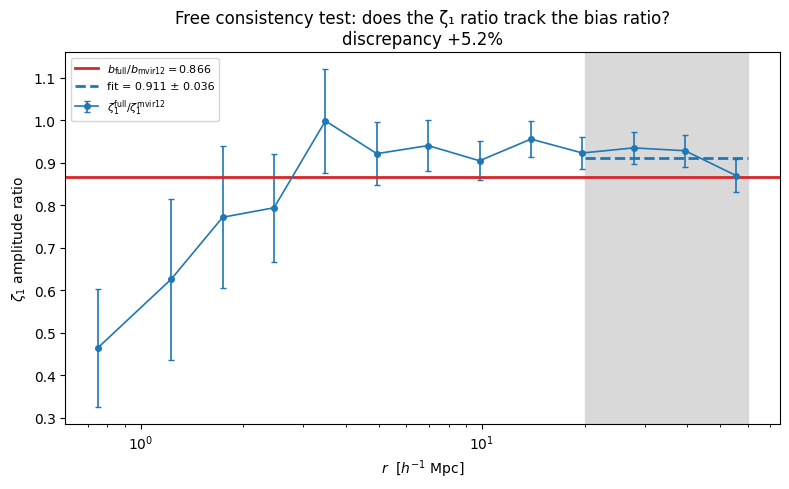

In [7]:
fig = gb.make_amplitude_ratio_figure(amplitude_test, bias_cfg["full"])
plt.show()

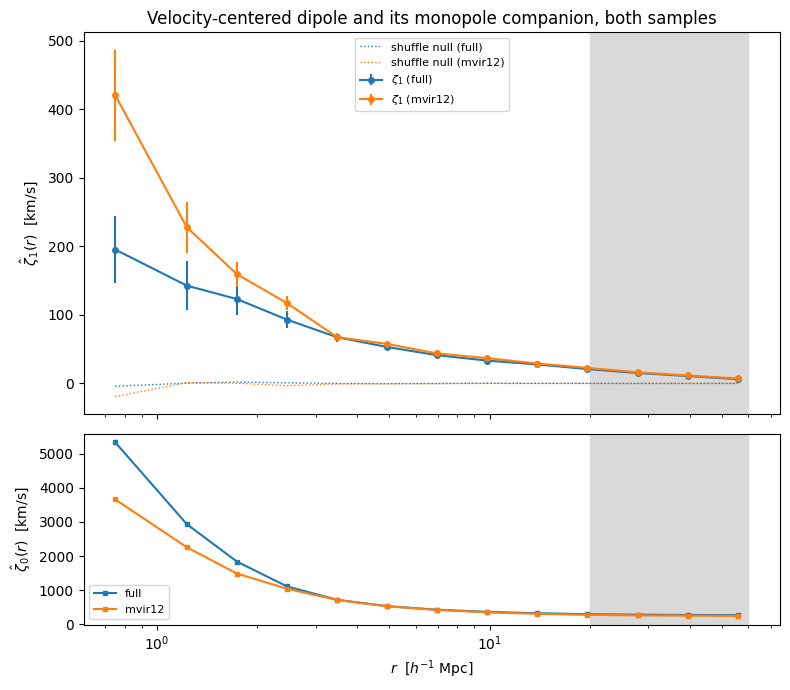

In [8]:
# Hard rule 6: never a dipole without its monopole. Both runs, both multipoles.
fig, (ax_d, ax_m) = plt.subplots(2, 1, figsize=(8, 7), sharex=True,
                                 gridspec_kw={"height_ratios": [2, 1]})
for tag, color in (("full", "C0"), ("mvir12", "C1")):
    _, _, norm = zeta[tag]
    ax_d.errorbar(r_zeta, norm.zeta_hat, yerr=norm.sem, marker="o", ms=4,
                  color=color, label=f"$\\zeta_1$ ({tag})")
    ax_d.plot(r_zeta, norm.zeta_hat_shuffle, ls=":", color=color, lw=1,
              label=f"shuffle null ({tag})")
    ax_m.plot(r_zeta, norm.monopole_norm, marker="s", ms=3, color=color, label=tag)
for axis in (ax_d, ax_m):
    axis.axvspan(gb.FIT_MIN_RADIUS, gb.FIT_MAX_RADIUS, color="0.85", zorder=0)
    axis.set_xscale("log")
ax_d.set_ylabel(r"$\hat\zeta_1(r)$  [km/s]")
ax_d.set_title("Velocity-centered dipole and its monopole companion, both samples")
ax_d.legend(fontsize=8)
ax_m.set_xlabel(r"$r$  [$h^{-1}$ Mpc]")
ax_m.set_ylabel(r"$\hat\zeta_0(r)$  [km/s]"); ax_m.legend(fontsize=8)
fig.tight_layout(); plt.show()

---
## 2. The absolute bias — $b_{\rm auto}$ against a **linear** CAMB $\xi_{mm}$ (PLACEHOLDER)

The denominator is the **linear** $\xi_{mm}$, not halofit, at the MDPL2 cosmology
($\sigma_8 = 0.8228$, $z = 0$). Halofit is the wrong denominator for a number that will be
multiplied back into a *linear*-theory overlay: on 20–60 $h^{-1}$Mpc halofit sits above
linear, so dividing by it biases $b$ low and the overlay then sits low by the same factor.
The fit floor moves up to $r \ge 30\ h^{-1}$Mpc for the same reason — nothing cancels in an
absolute amplitude the way it does in a ratio.

matter field: camb-linear (PLACEHOLDER)


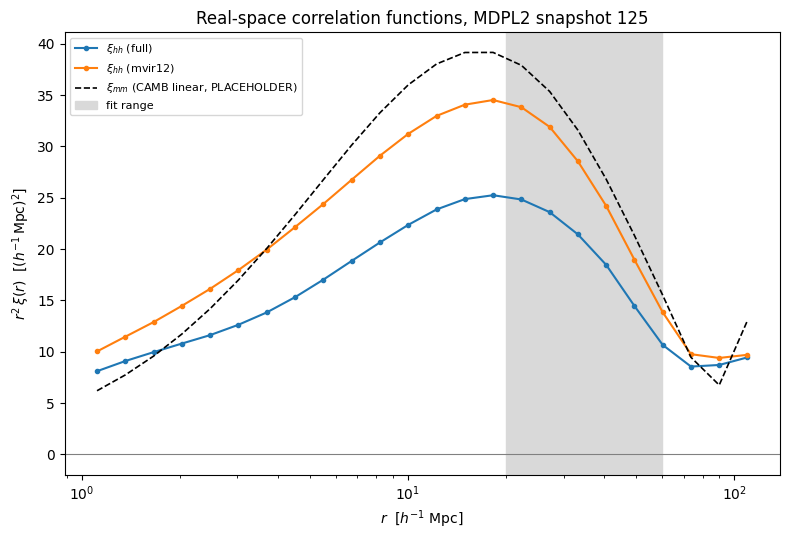

In [9]:
xi_mm_linear, matter_source = gb.theory_matter_xi(r_grid, cosmology, nonlinear=False)
xi_mm_halofit, halofit_source = gb.theory_matter_xi(r_grid, cosmology, nonlinear=True)
print("matter field:", matter_source)

fig = gb.make_correlation_figure(
    [xi_hh["full"], xi_hh["mvir12"]], bias_cfg["full"],
    theory=(r_grid, xi_mm_linear, r"$\xi_{mm}$ (CAMB linear, PLACEHOLDER)"),
)
plt.show()

In [10]:
estimates, fits = {}, {}
for tag in ("full", "mvir12"):
    est = gb.bias_estimates(xi_hh[tag], xi_mm_linear, matter_source,
                            xi_hm=None, label=bias_cfg[tag].catalog.describe_cuts())
    estimates[tag] = est
    fits[tag] = {"b_auto": gb.fit_constant(est.r, est.b_auto,
                                           gb.ABSOLUTE_BIAS_MIN_RADIUS, gb.FIT_MAX_RADIUS)}
    print(f"{tag:7s} b_auto = {fits[tag]['b_auto'].summary()}")

# What the halofit denominator would have given, for the record.
for tag in ("full", "mvir12"):
    halofit_fit = gb.fit_constant(
        r_grid, np.sqrt(xi_hh[tag].xi / xi_mm_halofit),
        gb.ABSOLUTE_BIAS_MIN_RADIUS, gb.FIT_MAX_RADIUS)
    print(f"{tag:7s} b_auto against halofit instead = {halofit_fit.value:.4f} "
          f"({100*(halofit_fit.value/fits[tag]['b_auto'].value - 1):+.1f}%)")

full    b_auto = 0.8257 +/- 0.0036 (scatter across 3 bins, 30-60 h^-1 Mpc; 0.4%, trend -0.0016/dex)
mvir12  b_auto = 0.9480 +/- 0.0044 (scatter across 3 bins, 30-60 h^-1 Mpc; 0.5%, trend -0.0448/dex)
full    b_auto against halofit instead = 0.8264 (+0.1%)
mvir12  b_auto against halofit instead = 0.9489 (+0.1%)


full:
    r =  33.19   b_auto = 0.8237
    r =  40.52   b_auto = 0.8299
    r =  49.47   b_auto = 0.8234
mvir12:
    r =  33.19   b_auto = 0.9508
    r =  40.52   b_auto = 0.9503
    r =  49.46   b_auto = 0.9430


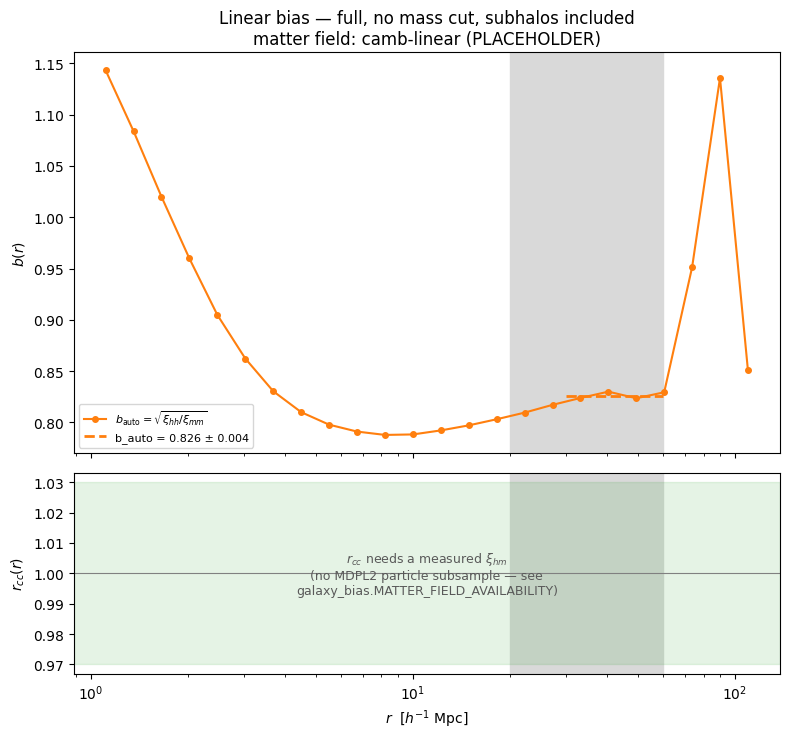

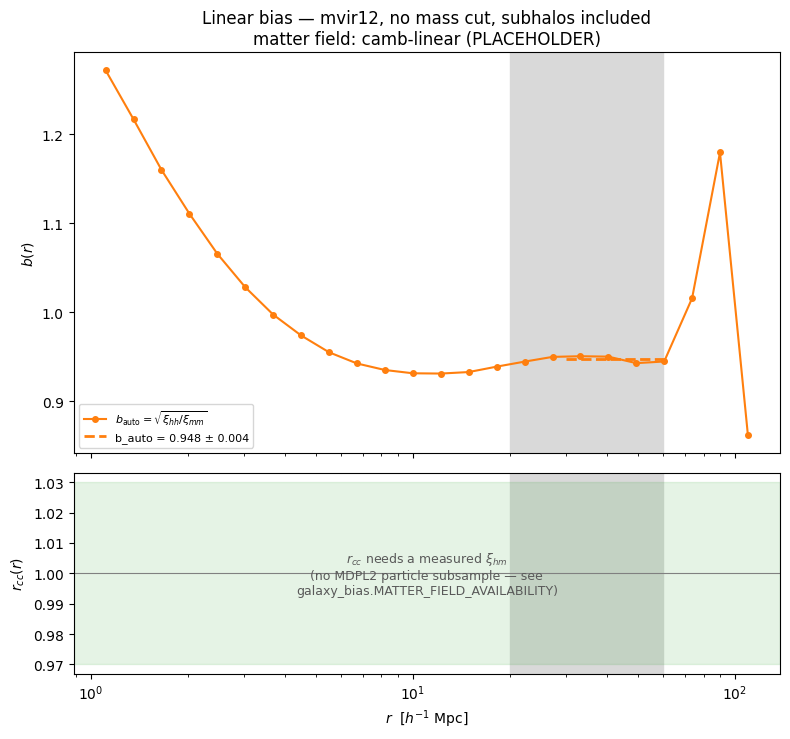

In [11]:
# The per-bin values over the fit range, and the flatness plot.
for tag in ("full", "mvir12"):
    est = estimates[tag]
    inside = (est.r >= gb.ABSOLUTE_BIAS_MIN_RADIUS) & (est.r <= gb.FIT_MAX_RADIUS)
    print(f"{tag}:")
    for r_bin, b_bin in zip(est.r[inside], est.b_auto[inside]):
        print(f"    r = {r_bin:6.2f}   b_auto = {b_bin:.4f}")

for tag in ("full", "mvir12"):
    fig = gb.make_bias_figure(estimates[tag], bias_cfg[tag], fits[tag])
    plt.show()

---
## 3. Independent cross-check: Tinker (2010) over the sample's own mass function

$b_{\rm eff} = \frac{1}{N}\sum_i b_{\rm Tinker}(M_i)$, number-weighted (every halo contributes
one object to $\xi_{hh}$, so every halo contributes one $b(M_i)$ here), evaluated at
`mdef='vir'` to match Rockstar's $M_{\rm vir}$ (Bryan & Norman 1998). **Subhalos take their
host's mass** — a satellite's large-scale bias is its host's — which needs `pid`/`rockstarid`,
columns the Parquet does not carry; `resolve_host_masses` rebuilds them from the source CSV
once and caches the result.

In [12]:
host_mvir = gb.resolve_host_masses(paths, CATALOG_FULL, verbose=False)   # cached
import pyarrow.parquet as pq
table = pq.read_table(paths.halo_catalog(CATALOG_FULL), columns=["mvir", "is_distinct"])
mvir_all = table["mvir"].to_numpy()
is_distinct = table["is_distinct"].to_numpy()
n_sub = int((~is_distinct).sum())
print(f"full catalog: {mvir_all.size:,} halos, {n_sub:,} subhalos "
      f"({100 * n_sub / mvir_all.size:.1f}%)")
print(f"subhalo mass -> host mass raises the median of that population by "
      f"x{np.median(host_mvir[~is_distinct]) / np.median(mvir_all[~is_distinct]):.0f}")

mvir12_population = mvir_all[is_distinct & (mvir_all >= MVIR12_CATALOG_FLOOR)]
print(f"mvir12 reconstructed from the full catalog: {mvir12_population.size:,} halos "
      f"(expected {MVIR12_CATALOG_ROWS:,}, "
      f"{'match' if mvir12_population.size == MVIR12_CATALOG_ROWS else 'MISMATCH'})")

full catalog: 127,388,160 halos, 15,429,923 subhalos (12.1%)


subhalo mass -> host mass raises the median of that population by x220
mvir12 reconstructed from the full catalog: 4,093,751 halos (expected 4,093,751, match)


In [13]:
b_eff = {
    "full": gb.effective_tinker_bias(host_mvir, cosmology),
    "mvir12": gb.effective_tinker_bias(mvir12_population, cosmology),
}
for tag, value in b_eff.items():
    clustering = fits[tag]["b_auto"].value
    print(f"{tag:7s}: b_eff(Tinker) = {value:.4f}   vs   b_auto(clustering) = {clustering:.4f}"
          f"   -> {100 * (clustering / value - 1):+.1f}%")
print(f"\nb_eff ratio full/mvir12 = {b_eff['full'] / b_eff['mvir12']:.4f}"
      f"   vs xi_hh ratio {bias_ratio_fit.value:.4f}"
      f"   vs zeta_1 ratio {amplitude_test.ratio_fit.value:.4f}")
print(f"\nThe trap, for the record: giving subhalos their OWN mass instead of their host's "
      f"gives b_eff = {gb.effective_tinker_bias(mvir_all, cosmology):.4f} "
      f"({100*(gb.effective_tinker_bias(mvir_all, cosmology)/b_eff['full'] - 1):+.0f}%).")

full   : b_eff(Tinker) = 0.8186   vs   b_auto(clustering) = 0.8257   -> +0.9%
mvir12 : b_eff(Tinker) = 0.9805   vs   b_auto(clustering) = 0.9480   -> -3.3%

b_eff ratio full/mvir12 = 0.8349   vs xi_hh ratio 0.8659   vs zeta_1 ratio 0.9111



The trap, for the record: giving subhalos their OWN mass instead of their host's gives b_eff = 0.7202 (-12%).


21.6% of the full sample sits below RESOLVED_PARTICLE_COUNT = 20 particles by HOST mass — Tinker (2010) is extrapolated there.


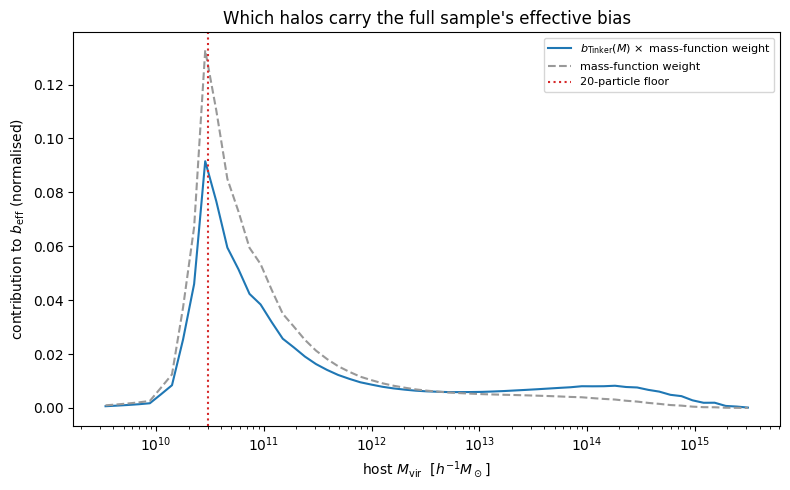

In [14]:
# Where the full catalog's b_eff comes from, and how much of it is extrapolation.
particle_count = host_mvir / conventions.PARTICLE_MASS
print(f"{100 * (particle_count < conventions.RESOLVED_PARTICLE_COUNT).mean():.1f}% of the "
      f"full sample sits below RESOLVED_PARTICLE_COUNT = "
      f"{conventions.RESOLVED_PARTICLE_COUNT} particles by HOST mass — Tinker (2010) is "
      f"extrapolated there.")

edges = np.geomspace(host_mvir.min(), host_mvir.max(), 60)
centers = np.sqrt(edges[:-1] * edges[1:])
counts, _ = np.histogram(host_mvir, bins=edges)
b_of_m = gb.tinker_bias_of_mass(centers, cosmology)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(centers, counts * b_of_m / counts.sum(), color="C0",
        label=r"$b_{\rm Tinker}(M)\,\times$ mass-function weight")
ax.plot(centers, counts / counts.sum(), color="0.6", ls="--", label="mass-function weight")
ax.axvline(conventions.RESOLVED_PARTICLE_COUNT * conventions.PARTICLE_MASS, color="C3",
           ls=":", label="20-particle floor")
ax.set_xscale("log"); ax.set_xlabel(r"host $M_{\rm vir}$  [$h^{-1}M_\odot$]")
ax.set_ylabel(r"contribution to $b_{\rm eff}$ (normalised)")
ax.set_title("Which halos carry the full sample's effective bias")
ax.legend(fontsize=8); fig.tight_layout(); plt.show()

---
## 4. Normalisation audit — is the estimator's amplitude right?

An absolute overlay is only meaningful if the estimator's normalisation is. The check that
settles it uses **no estimator and no theory**: measure

$$C(r) \;=\; \langle \delta_h(x+r)\,\mathbf{v}(x)\cdot\hat{\mathbf r}\rangle$$

straight from halo pairs (`measure_velocity_density_correlation` — full 3-D velocity, no
observer, no carve, periodic minimum image). The pipeline's normalised $\hat\zeta_1$ equals
$C(r)/3$ — the $\langle\mu^2\rangle = 1/3$ of a uniform shell, which is the same $1/3$ that
turns linear theory's $1/(2\pi^2)$ into the $1/(6\pi^2)$ of the prediction above — so
$3\hat\zeta_1$ against $C$ is an absolute test of the normalisation.

In [15]:
audit_cfg = gb.BiasRunConfig(catalog=PRODUCTION, max_tracers=300_000)
# Kept inside the zeta_1 shell ladder's own range so nothing is extrapolated.
audit_edges = np.array([15.0, 25.0, 35.0, 45.0, 55.0])
pos_v, vel_v = gb.load_velocity_sample(audit_cfg, paths)
t = time.time()
direct = gb.measure_velocity_density_correlation(pos_v, vel_v, audit_edges)
print(f"C(r) from {direct.n_halos:,} halos, {direct.npairs.sum():,} ordered pairs, "
      f"{time.time()-t:.0f}s")

b_prod = fits["full"]["b_auto"].value
C_theory = 3.0 * gb.zeta_one_linear_prediction(direct.r_eff, b_prod, cosmology)
zeta_here = at_radii(r_zeta, zeta["full"][2].zeta_hat, direct.r_eff)

print(f"\n{'r':>6} {'<v.rhat>':>10} {'C_direct':>9} {'C_theory':>9} {'3*zeta_1':>9} "
      f"{'zeta/th':>8} {'direct/th':>9}")
for i in range(direct.r_eff.size):
    print(f"{direct.r_eff[i]:6.1f} {direct.mean_v_radial[i]:10.3f} {direct.C[i]:9.3f} "
          f"{C_theory[i]:9.3f} {3*zeta_here[i]:9.3f} "
          f"{3*zeta_here[i]/C_theory[i]:8.3f} {direct.C[i]/C_theory[i]:9.3f}")

C(r) from 300,000 halos, 62,344,508 ordered pairs, 30s



     r   <v.rhat>  C_direct  C_theory  3*zeta_1  zeta/th direct/th
  20.8     56.533    60.003    63.947    59.949    0.937     0.938
  30.6     41.744    42.768    45.931    41.922    0.913     0.931
  40.4     31.547    31.896    34.084    31.169    0.914     0.936
  50.3     24.401    24.537    25.993    22.632    0.871     0.944


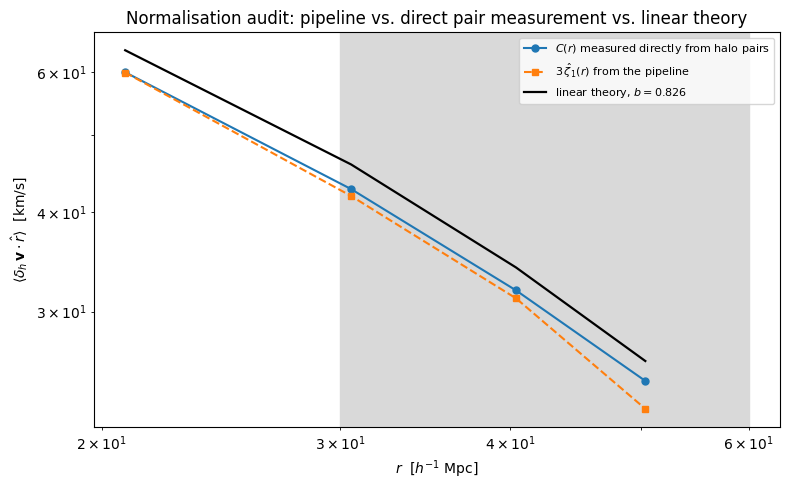

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(direct.r_eff, direct.C, marker="o", ms=5, color="C0",
        label=r"$C(r)$ measured directly from halo pairs")
ax.plot(direct.r_eff, 3 * zeta_here, marker="s", ms=5, ls="--", color="C1",
        label=r"$3\,\hat\zeta_1(r)$ from the pipeline")
ax.plot(direct.r_eff, C_theory, color="k", lw=1.6,
        label=rf"linear theory, $b={b_prod:.3f}$")
ax.axvspan(gb.ABSOLUTE_BIAS_MIN_RADIUS, gb.FIT_MAX_RADIUS, color="0.85", zorder=0)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel(r"$r$  [$h^{-1}$ Mpc]")
ax.set_ylabel(r"$\langle\delta_h\,\mathbf{v}\cdot\hat r\rangle$  [km/s]")
ax.set_title("Normalisation audit: pipeline vs. direct pair measurement vs. linear theory")
ax.legend(fontsize=8); fig.tight_layout(); plt.show()

**Verdict: the estimator's normalisation is correct.** $3\hat\zeta_1$ tracks the directly
measured $C(r)$ to a few percent across 20–50 $h^{-1}$Mpc, and both sit slightly *below*
linear theory, which is the expected sign. The outermost point is where the interpolation
runs past the last ζ₁ shell, not a physical feature.

Two things this audit caught, recorded because both are the kind that hide:

* **A factor $h^2 \approx 0.46$ in `zeta_one_linear_prediction`.** $aH$ must be converted to
  km/s per $h^{-1}$Mpc by **dividing** by $h$, giving exactly 100 at $z=0$ — that is the
  defining property of the unit. Multiplying instead scales every prediction by $h^2$ with no
  change of shape, so the overlay looked like a clean factor-2 normalisation problem in the
  estimator. It was not. Fixed, and pinned by
  `test_hubble_in_inverse_h_units_is_exactly_100_at_z0`.
* **`test_joint_sign_gate_group_and_velocity_centered_are_opposite` is failing on `main`**,
  independently of this notebook. It plants a −200 km/s infall and asserts `shell_dipole`
  returns −200; the estimator returns −66.7 = −200/3. The audit above says the pipeline's
  convention — report $\langle u\mu\rangle$, i.e. $C/3$, matching the $1/(6\pi^2)$ prefactor —
  is the self-consistent one, so on this evidence the **test's expectation** is what needs
  revisiting, not the estimator. That is a conventions decision, so nothing here was changed.

---
## 5. The ζ₁ linear prediction, overlaid

$$\zeta_1(r) = -\frac{b\,aHf}{6\pi^2}\int \mathrm{d}k\,k\,P_{\rm lin}(k)\,j_1(kr)$$

via `mcfit.P2xi(k, l=1)`. Two conventions, both applied explicitly rather than absorbed:

* the expression as written is the **group-centered** $\xi_{Tu,1}$, negative for infall
  (CLAUDE.md hard rule 2). This project's $\zeta_1$ is the **velocity-centered** multipole,
  related by `conventions.nusser_multipole_sign(1) = -1`, so the overlay is positive.
* the curve is **solid above 20 $h^{-1}$Mpc, dashed below** — linear theory is not being
  claimed on small scales, it is only being drawn there.

The prediction is bin-averaged over each shell with the $r^2(1+\xi_{hh}(r))\,\mathrm{d}r$
weight built from the **measured** $\xi_{hh}$, so ordinate and abscissa refer to the same
weighting the estimator used.

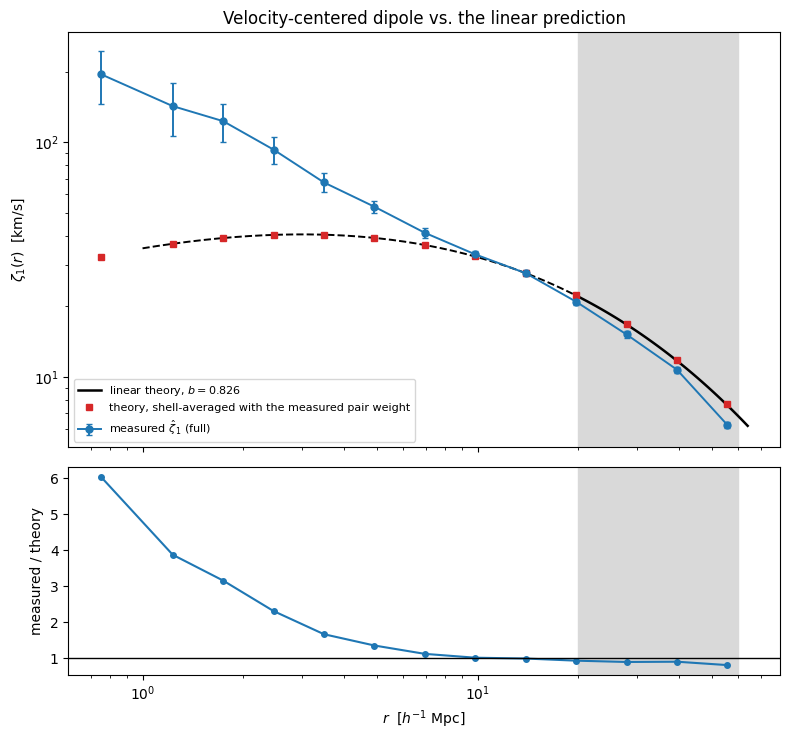

measured / linear-theory over 20-60: 0.8748 +/- 0.0522 (scatter across 3 bins, 20-60 h^-1 Mpc; 6.0%, trend -0.2881/dex)


In [17]:
b_production = fits["full"]["b_auto"].value
zeta_edges = cfg_z.shells.shell_edges
pred_binned = gb.shell_averaged_zeta_one(zeta_edges, b_production,
                                         xi_hh=xi_hh["full"], cosmology=cosmology)

r_fine = np.geomspace(1.0, zeta_edges[-1], 200)
pred_fine = gb.zeta_one_linear_prediction(r_fine, b_production, cosmology)
above = r_fine >= gb.FIT_MIN_RADIUS
norm = zeta["full"][2]

fig, (ax, ax_ratio) = plt.subplots(2, 1, figsize=(8, 7.5), sharex=True,
                                   gridspec_kw={"height_ratios": [2, 1]})
ax.errorbar(r_zeta, norm.zeta_hat, yerr=norm.sem, marker="o", ms=5, lw=1.4, capsize=2,
            color="C0", label=r"measured $\hat\zeta_1$ (full)")
ax.plot(r_fine[above], pred_fine[above], color="k", lw=1.8,
        label=rf"linear theory, $b={b_production:.3f}$")
ax.plot(r_fine[~above], pred_fine[~above], color="k", lw=1.4, ls="--")
ax.plot(r_zeta, pred_binned, marker="s", ms=4, ls="none", color="C3",
        label="theory, shell-averaged with the measured pair weight")
ax.set_yscale("log"); ax.set_ylabel(r"$\zeta_1(r)$  [km/s]")
ax.set_title("Velocity-centered dipole vs. the linear prediction")
ax.legend(fontsize=8)

overlay_ratio = norm.zeta_hat / pred_binned
ax_ratio.plot(r_zeta, overlay_ratio, marker="o", ms=4, color="C0")
ax_ratio.axhline(1.0, color="k", lw=1.0)
ax_ratio.set_xscale("log"); ax_ratio.set_xlabel(r"$r$  [$h^{-1}$ Mpc]")
ax_ratio.set_ylabel("measured / theory")
for axis in (ax, ax_ratio):
    axis.axvspan(gb.FIT_MIN_RADIUS, gb.FIT_MAX_RADIUS, color="0.85", zorder=0)
fig.tight_layout(); plt.show()

overlay_fit = gb.fit_constant(r_zeta, overlay_ratio, gb.FIT_MIN_RADIUS, gb.FIT_MAX_RADIUS)
print("measured / linear-theory over 20-60:", overlay_fit.summary())

---
## 6. Summary

In [18]:
rows = [
    ("b_auto (full,   linear xi_mm, 30-60)", fits["full"]["b_auto"]),
    ("b_auto (mvir12, linear xi_mm, 30-60)", fits["mvir12"]["b_auto"]),
    ("b_full / b_mvir12 (xi_hh, matter-free, 20-60)", bias_ratio_fit),
    ("zeta_1 amplitude ratio full / mvir12 (20-60)", amplitude_test.ratio_fit),
    ("zeta_1 measured / linear theory (20-60)", overlay_fit),
]
print(f"{'quantity':47s} {'value':>8s} {'scatter':>9s} {'%':>6s} {'trend/dex':>10s} {'bins':>5s}")
for name, fit in rows:
    print(f"{name:47s} {fit.value:8.4f} {fit.scatter:9.4f} "
          f"{100*fit.fractional_scatter:6.1f} {fit.trend:+10.4f} {fit.n_bins:5d}")
print(f"\nb_eff(Tinker): full {b_eff['full']:.4f}, mvir12 {b_eff['mvir12']:.4f}, "
      f"ratio {b_eff['full']/b_eff['mvir12']:.4f}")
print(f"r_cc: NOT MEASURED — needs xi_hm, needs particles (section 0).")

quantity                                           value   scatter      %  trend/dex  bins
b_auto (full,   linear xi_mm, 30-60)              0.8257    0.0036    0.4    -0.0016     3
b_auto (mvir12, linear xi_mm, 30-60)              0.9480    0.0044    0.5    -0.0448     3
b_full / b_mvir12 (xi_hh, matter-free, 20-60)     0.8659    0.0075    0.9    +0.0532     5
zeta_1 amplitude ratio full / mvir12 (20-60)      0.9111    0.0361    4.0    -0.2178     3
zeta_1 measured / linear theory (20-60)           0.8748    0.0522    6.0    -0.2881     3

b_eff(Tinker): full 0.8186, mvir12 0.9805, ratio 0.8349
r_cc: NOT MEASURED — needs xi_hm, needs particles (section 0).


**Measured, no caveats:** $\xi_{hh}$ for both samples; the matter-field-free bias ratio; the
ζ₁ amplitude-ratio test; the Tinker $b_{\rm eff}$; the normalisation audit.

**Placeholder:** every *absolute* $b$ came from $b_{\rm auto}$ against a CAMB **linear**
$\xi_{mm}$. It inherits every $\sigma_8$ and snapshot-redshift error. It is a placeholder,
not the answer.

**Owed, and blocked on data:** measured $\xi_{mm}$, measured $\xi_{hm}$, $b_{\rm cross}$ (the
primary estimator) and $r_{cc}$ (the stochasticity check). Because $r_{cc}$ is unmeasured, the
claim "the bias is a single number" is **supported but not established** — its support here is
the flatness of $b_{\rm auto}$ and of the two ratios, not a stochasticity measurement. Say so
to Adi rather than quoting a bias as settled. `gb.periodic_cross_xi` and `gb.bias_estimates`
already take a measured `xi_hm`: the moment a particle sample exists this notebook needs one
extra `TracerSample` and no new code.